# Document Type Classification - Exploratory Data Analysis (EDA)

이 노트북은 문서 타입 분류 경진대회 데이터를 분석하여 모델 성능 향상을 위한 인사이트를 얻기 위해 작성되었습니다.

## 분석 목표
1. 데이터 분포 확인 (Class Imbalance)
2. 이미지 특성 분석 (Resolution, Aspect Ratio)
3. 시각적 특징 파악 (샘플 시각화)
4. **Train vs Test 분포 비교** (Distribution Shift 확인)
5. **클래스별 밝기 분석 및 텍스트 영역 비율 추정**
6. 전처리 및 Augmentation 전략 수립

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import glob

# 시각화 설정
plt.style.use('ggplot')
sns.set_palette("viridis")

## 1. 데이터 로드 및 기본 정보 확인

In [14]:
PROJECT_ROOT = Path("../../..")
DATA_DIR = PROJECT_ROOT / "data/raw"
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_IMG_DIR = DATA_DIR / "train"
TEST_IMG_DIR = DATA_DIR / "test"

train_df = pd.read_csv(TRAIN_CSV)
test_images = [os.path.basename(x) for x in glob.glob(str(TEST_IMG_DIR / "*"))]

print(f"Total training samples: {len(train_df)}")
print(f"Total testing samples: {len(test_images)}")
train_df.head()

Total training samples: 1570
Total testing samples: 3140


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


## 2. 클래스 분포 분석 (Train Only)

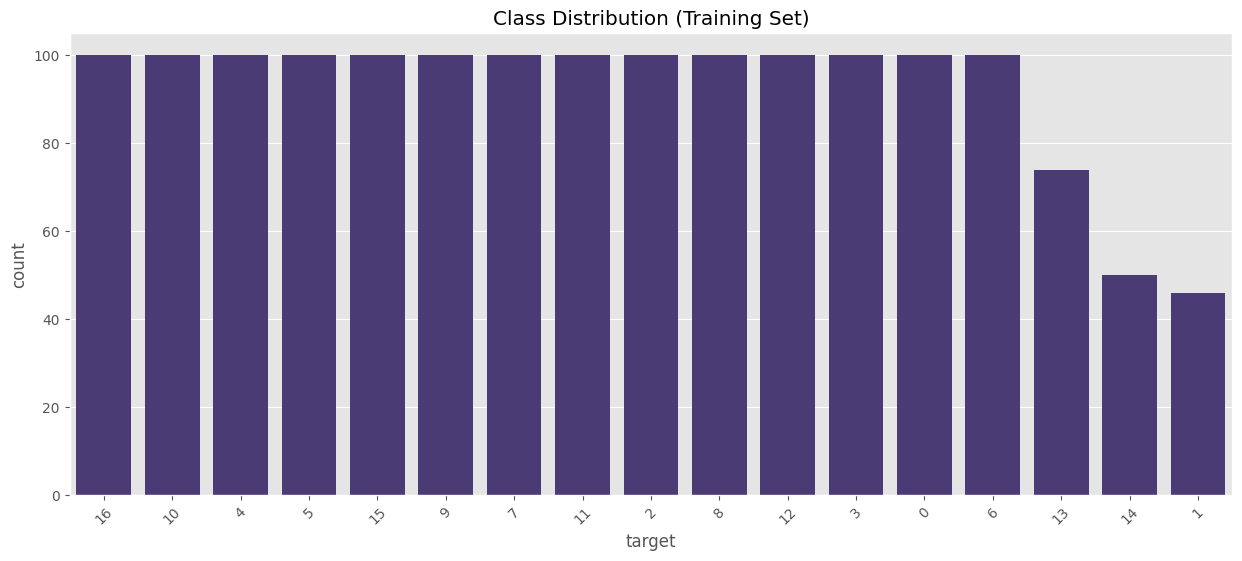

Counts per class:
target
16    100
10    100
4     100
5     100
15    100
9     100
7     100
11    100
2     100
8     100
12    100
3     100
0     100
6     100
13     74
14     50
1      46
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(15, 6))
sns.countplot(data=train_df, x='target', order=train_df['target'].value_counts().index)
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.show()

print("Counts per class:")
print(train_df['target'].value_counts())

## 3. Train vs Test 분포 비교 (해상도 및 종횡비)

In [16]:
def get_image_info_from_list(img_dir, img_ids):
    info = []
    for img_id in tqdm(img_ids):
        img_path = img_dir / img_id
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                info.append({"width": w, "height": h, "ratio": w/h})
        except Exception as e:
            print(f"Error loading {img_id}: {e}")
    return pd.DataFrame(info)

print("Analyzing Train Images...")
train_info_df = get_image_info_from_list(TRAIN_IMG_DIR, train_df['ID'])
print("Analyzing Test Images...")
test_info_df = get_image_info_from_list(TEST_IMG_DIR, test_images)

train_info_df['set'] = 'train'
test_info_df['set'] = 'test'
all_info_df = pd.concat([train_info_df, test_info_df])

Analyzing Train Images...


100%|██████████| 1570/1570 [00:00<00:00, 19913.50it/s]


Analyzing Test Images...


100%|██████████| 3140/3140 [00:00<00:00, 20824.19it/s]


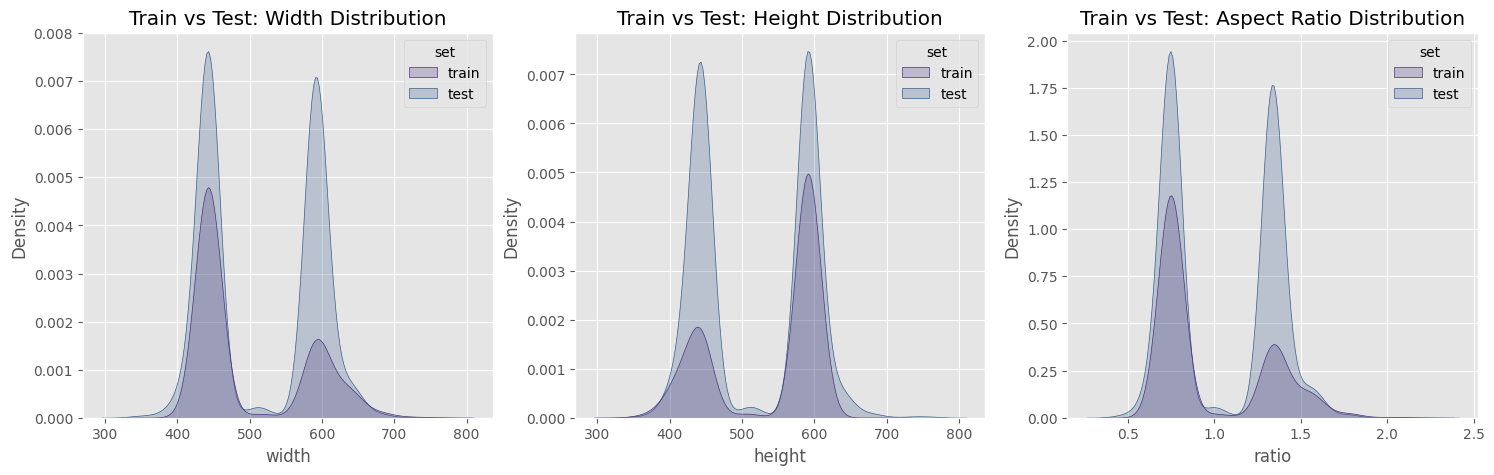

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.kdeplot(data=all_info_df, x='width', hue='set', ax=axes[0], fill=True)
axes[0].set_title("Train vs Test: Width Distribution")
sns.kdeplot(data=all_info_df, x='height', hue='set', ax=axes[1], fill=True)
axes[1].set_title("Train vs Test: Height Distribution")
sns.kdeplot(data=all_info_df, x='ratio', hue='set', ax=axes[2], fill=True)
axes[2].set_title("Train vs Test: Aspect Ratio Distribution")
plt.show()

## 4. 클래스별 상세 분석 (밝기 & 텍스트 영역 비율)

### 4.1 클래스별 밝기 분포 분석
특정 클래스가 유독 어둡거나 밝은지 확인하여 클래스별 맞춤 증강 또는 전처리(CLAHE 등)의 필요성을 검토합니다.

Analyzing class brightness: 100%|██████████| 17/17 [00:00<00:00, 48.54it/s]


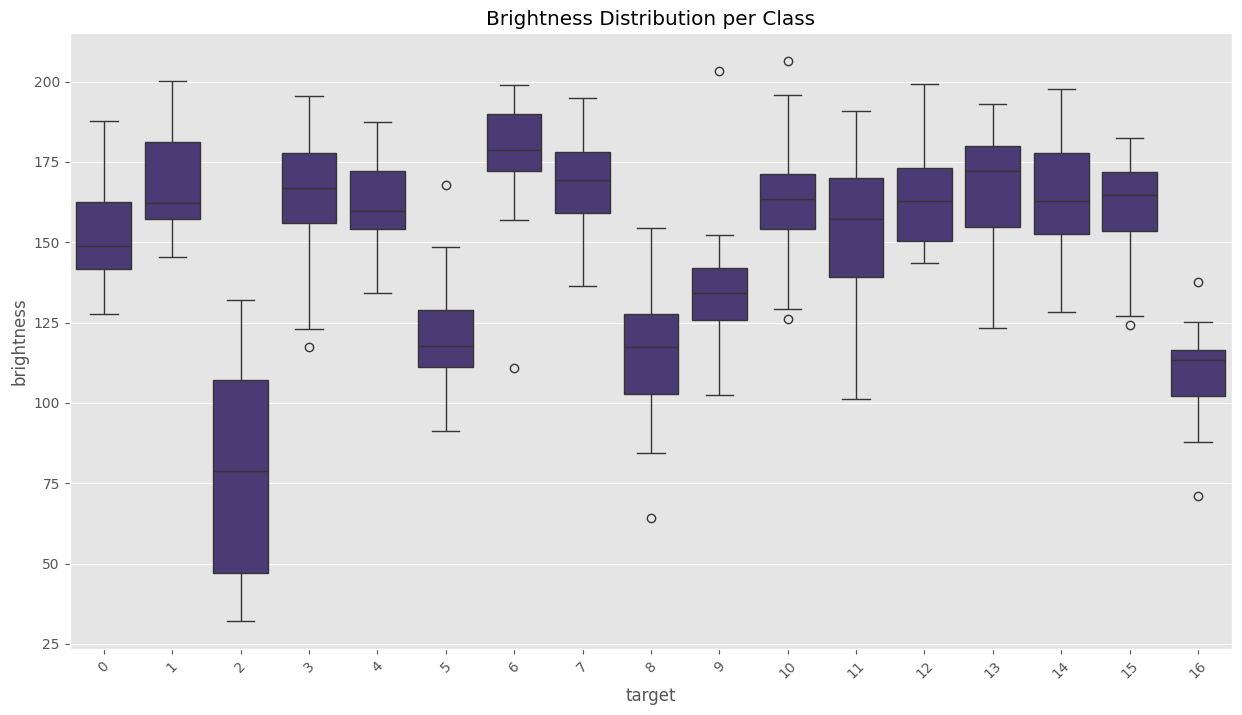

In [18]:
def analyze_class_brightness(img_dir, df, n_per_class=20):
    brightness_data = []
    classes = sorted(df['target'].unique())
    
    for cls in tqdm(classes, desc="Analyzing class brightness"):
        cls_samples = df[df['target'] == cls].sample(min(n_per_class, len(df[df['target'] == cls])))
        for img_id in cls_samples['ID']:
            img = cv2.imread(str(img_dir / img_id), cv2.IMREAD_GRAYSCALE)
            brightness_data.append({"target": cls, "brightness": np.mean(img)})
            
    return pd.DataFrame(brightness_data)

class_brightness_df = analyze_class_brightness(TRAIN_IMG_DIR, train_df)

plt.figure(figsize=(15, 8))
sns.boxplot(data=class_brightness_df, x='target', y='brightness')
plt.title("Brightness Distribution per Class")
plt.xticks(rotation=45)
plt.show()

### 4.2 텍스트 영역 비율 추정 (Heuristic)
문서 이미지에서 글자가 차지하는 영역의 비율을 추정합니다. 이 수치가 낮을수록 글자가 드문드문 있다는 뜻이므로, `RandomResizedCrop` 사용 시 글자 영역을 놓치지 않도록 `scale` 범위를 조심스럽게 설정해야 합니다.

Estimating text ratio: 100%|██████████| 100/100 [00:00<00:00, 603.95it/s]


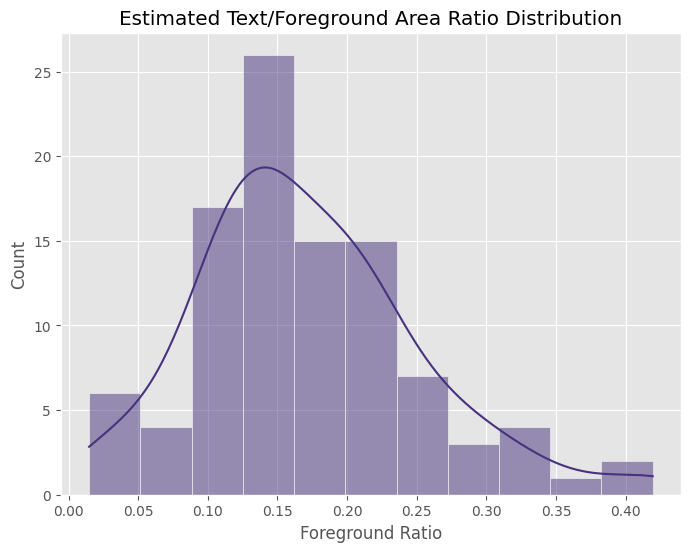

Mean foreground ratio: 0.1716
Min foreground ratio: 0.0147


In [19]:
def estimate_text_ratio(img_dir, df, n_samples=100):
    ratios = []
    samples = df.sample(min(n_samples, len(df)))
    
    for img_id in tqdm(samples['ID'], desc="Estimating text ratio"):
        img = cv2.imread(str(img_dir / img_id), cv2.IMREAD_GRAYSCALE)
        # Adaptive thresholding to find foreground (text/lines)
        binary = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                      cv2.THRESH_BINARY_INV, 11, 2)
        # Count foreground pixels
        ratio = np.sum(binary > 0) / (binary.shape[0] * binary.shape[1])
        ratios.append(ratio)
        
    return ratios

text_ratios = estimate_text_ratio(TRAIN_IMG_DIR, train_df)

plt.figure(figsize=(8, 6))
sns.histplot(text_ratios, kde=True)
plt.title("Estimated Text/Foreground Area Ratio Distribution")
plt.xlabel("Foreground Ratio")
plt.show()

print(f"Mean foreground ratio: {np.mean(text_ratios):.4f}")
print(f"Min foreground ratio: {np.min(text_ratios):.4f}")

## 5. 데이터셋 샘플 시각화

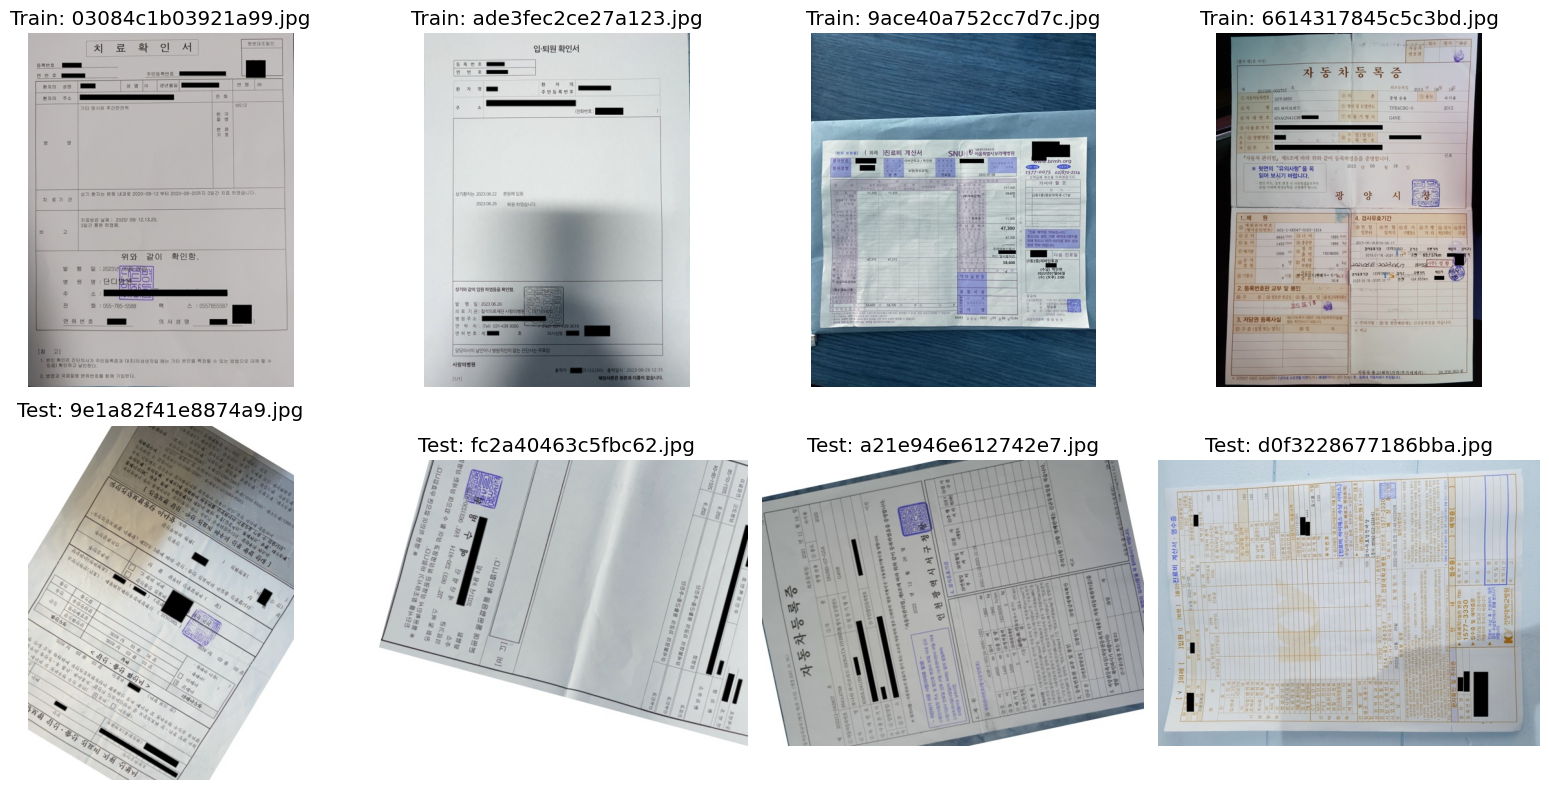

In [20]:
def plot_set_samples(train_dir, train_ids, test_dir, test_ids, n=4):
    fig, axes = plt.subplots(2, n, figsize=(n*4, 8))
    for i in range(n):
        img_id = np.random.choice(train_ids)
        img = cv2.imread(str(train_dir / img_id))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0][i].imshow(img)
        axes[0][i].set_title(f"Train: {img_id}")
        axes[0][i].axis('off')
    for i in range(n):
        img_id = np.random.choice(test_ids)
        img = cv2.imread(str(test_dir / img_id))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1][i].imshow(img)
        axes[1][i].set_title(f"Test: {img_id}")
        axes[1][i].axis('off')
    plt.tight_layout()
    plt.show()

plot_set_samples(TRAIN_IMG_DIR, train_df['ID'].tolist(), TEST_IMG_DIR, test_images)

## 6. 결론 및 전략 수립 (인사이트)

### 클래스별/데이터셋 분석 점검 항목
- **Class-specific Brightness**: 유독 어두운 클래스(예: 신분증 스캔본 등)가 있다면 `CLAHE`나 `RandomBrightnessContrast`를 해당 클래스에 더 집중하거나 전역적으로 강화해야 합니다.
- **Text Area Ratio**: 글자 비율이 매우 낮은 문서가 있다면, `RandomResizedCrop`의 `scale` 범위를 (0.08, 1.0) 처럼 너무 낮게 잡을 경우 빈 여백만 학습될 위험이 있습니다. 보수적으로 (0.5, 1.0) 정도로 잡는 것이 안전할 수 있습니다.
- **Train-Test Shift**: Train과 Test의 해상도나 밝기 분포가 다르면, 학습 시 해당 부분을 보정하는 Augmentation이 필수입니다.

### 추천 Augmentation 수정 전략
1. **학습 영역 보존**: 텍스트 비율에 따라 `RandomResizedCrop`의 `scale` 하한값 조정
2. **조명 보정**: 클래스별 밝기 차이를 극복하기 위한 `RandomBrightnessContrast` 또는 `ColorJitter` 활용
3. **도메인 적응**: Test 시각화에서 발견된 특이점(그림자, 노이즈 등)을 `GaussNoise`, `FancyPCA` 등으로 모사